# t^* distrabution analysis


---
## 1. Imports & Setup

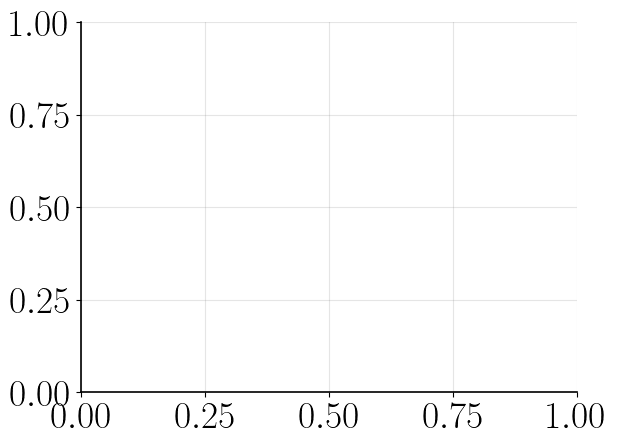

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
from scipy.stats import linregress
import os

def make_path_exist(filepath):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)

def save_simple_dict_to_csv(data: dict, filepath: str):
    """Save {float -> scalar or list} dict to CSV."""
    make_path_exist(filepath)
    rows = []
    for k, v in sorted(data.items()):
        if hasattr(v, '__len__'):
            rows.append({"aval": k, "value": v[0], "value_err": v[1]})
        else:
            rows.append({"aval": k, "value": v})
    pd.DataFrame(rows).to_csv(filepath, index=False)


def set_default_plot_style():
    plt.style.use("default")  # start clean

    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2
    plt.rcParams["grid.linestyle"] = "-"
    plt.rcParams["grid.color"] = "gray"

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    plt.rcParams["axes.linewidth"] = 1.2

    plt.rcParams["legend.frameon"] = False

    plt.rcParams["font.size"] = 27
    plt.rcParams["axes.labelsize"] = 32
    plt.rcParams["legend.fontsize"] = 21

    # plt.rcParams["font.size"] = 18
    # plt.rcParams["axes.labelsize"] = 24
    # plt.rcParams["legend.fontsize"] = 12

    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Computer Modern Roman']

# Call once at the top of your script
set_default_plot_style()
ax = plt.gca() # color = ax._get_lines.get_next_color()

---
## 2. Global Parameters

In [ ]:
J   = 1
tau = 1 * J

N_val = 4

num_unit_cells_vals = [8, 16, 32, 64, 128]  # adjust as needed
# num_unit_cells_vals = [64]  # adjust as needed
num_uc = len(num_unit_cells_vals)

# Blue palette: light -> dark
blue_colors = [mcolors.to_rgba(c) for c in
               plt.cm.Blues(np.linspace(0.35, 0.85, num_uc))]

num_initial_conds = 300

a_vals = [
    0.68, 0.7, 0.71
]
# a_vals = [0.68, 0.69, 0.7, 0.71, 0.72, 0.74, 0.76]
# a_vals = [0.68]

z_val      = 1.7
z_val_name = str(z_val).replace(".", "p")
z_fit_val  = 1.7
z_fit_name = str(z_fit_val).replace(".", "p")

parent_data_path = "/Volumes/ExternalData"  # <- adjust as needed

---
## 3. Load Raw Samples, Compute Averages, Save to Disk


In [ ]:
# collected_S_diffs_mean[L][a_val]     = np.array of shape (n,)  -- mean over ICs
# collected_S_diff_SEMs[L][a_val] = np.array of shape (n,)  -- SEM over ICs
collected_S_diffs_mean     = {}
collected_S_diffs = {}
collected_S_diff_SEMs = {}

for num_unit_cells in num_unit_cells_vals:
    L = num_unit_cells * N_val
    print(f"L = {L}")
    n = int(round(L ** z_fit_val))

    collected_S_diffs_mean[L]     = {}
    collected_S_diffs[L]     = {}
    collected_S_diff_SEMs[L] = {}

    for a_val in a_vals:
        a_name = str(a_val).replace(".", "p")
        all_ic_diffs = np.zeros((num_initial_conds, n))

        for ic in range(1, num_initial_conds + 1):
            
            try:
                filepath = (
                    f"{parent_data_path}/spin_dists_per_time/N{N_val}/a{a_name}/IC1/L{L}/"
                    f"N{N_val}_a{a_name}_IC1_L{L}_z{z_val_name}_sample{ic}.csv"
                    )
                df = pd.read_csv(filepath, usecols=["delta_s"])
            except Exception as e:
                filepath = (
                    f"{parent_data_path}/spin_dists_per_time/N{N_val}/a{a_name}/IC1/L{L}/"
                    f"N{N_val}_a{a_name}_IC1_L{L}_z1p7_sample{ic}.csv"
                    )
                df = pd.read_csv(filepath, usecols=["delta_s"])

            collected_S_diffs_mean[L][a_val] = 
            all_ic_diffs[ic - 1] = df["delta_s"].values[:n]

        collected_S_diffs_mean[L][a_val]     = all_ic_diffs.mean(axis=0)
        collected_S_diff_SEMs[L][a_val] = all_ic_diffs.std(axis=0, ddof=1) / np.sqrt(num_initial_conds)

    # Save using numpy .npz (replaces Julia's binary serialize)
    a_range = f"{min(a_vals)}_{max(a_vals)}".replace(".", "p")
    out_dir = f"data/s_diffs_tf/N{N_val}/SeveralAs/IC{num_initial_conds}/L{L}/"
    os.makedirs(out_dir, exist_ok=True)
    fname = f"N{N_val}_ar{a_range}_IC{num_initial_conds}_L{L}_z{z_fit_name}"

    np.savez(out_dir + fname + "_avg.npz", **{str(a).replace(".","p"): v for a, v in collected_S_diffs_mean[L].items()})
    np.savez(out_dir + fname + "_sem.npz", **{str(a).replace(".","p"): v for a, v in collected_S_diff_SEMs[L].items()})
    print(f"  Saved: {out_dir + fname}")

L = 32


FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/ExternalData/spin_dists_per_time/N4/a0p68/IC1/L32/N4_a0p68_IC1_L32_z1p7_sample1.csv'

---
## 4. Load From Saved `.npz` Files

In [ ]:
collected_S_diffs_mean     = {}
collected_S_diff_SEMs = {}

for num_unit_cells in num_unit_cells_vals:
    L = num_unit_cells * N_val
    print(f"Loading L = {L}")

    a_range = f"{min(a_vals)}_{max(a_vals)}".replace(".", "p")
    base = (
        f"data/s_diffs_tf/N{N_val}/SeveralAs/IC{num_initial_conds}/L{L}/"
        f"N{N_val}_ar{a_range}_IC{num_initial_conds}_L{L}_z{z_fit_name}"
    )
    print(base)

    avg_data = np.load(base + "_avg.npz")
    sem_data = np.load(base + "_sem.npz")

    # Convert keys back from "0p762" -> 0.762
    collected_S_diffs_mean[L]     = {float(k.replace("p", ".")): avg_data[k] for k in avg_data}
    collected_S_diff_SEMs[L] = {float(k.replace("p", ".")): sem_data[k] for k in sem_data}

print("Done loading.")

Loading L = 32
data/s_diffs_tf/N4/SeveralAs/IC1000/L32/N4_ar0p68_0p71_IC1000_L32_z1p7


FileNotFoundError: [Errno 2] No such file or directory: 'data/s_diffs_tf/N4/SeveralAs/IC1000/L32/N4_ar0p68_0p71_IC1000_L32_z1p7_avg.npz'

---
## 5. S_diff(t) Time Traces for a Single L

Saved: figs/delta_evolved_spins/N4/SeveralAs/IC1000/L256/S_diff_N4_L256_z1p7.png


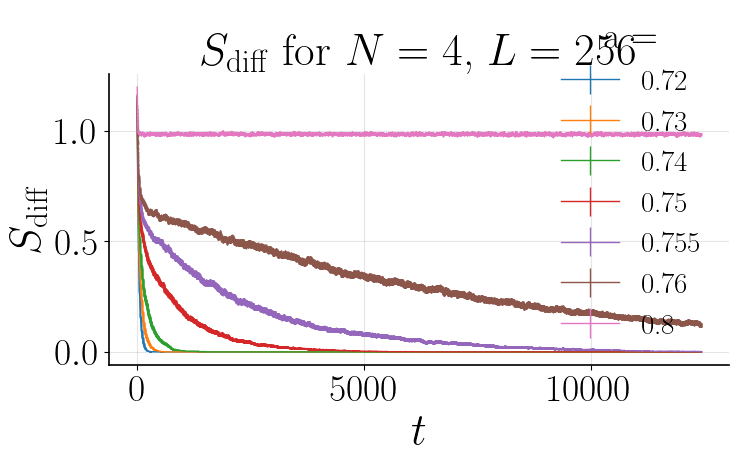

In [ ]:
a_vals_to_plot       = [0.72, 0.73, 0.74, 0.75, 0.755, 0.76, 0.8]
num_unit_cell_plot   = 64
L_plot               = num_unit_cell_plot * N_val
n_plot               = int(round(L_plot ** z_fit_val))

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(rf"$S_{{\mathrm{{diff}}}}$ for $N={N_val}$, $L={L_plot}$")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$S_{\mathrm{diff}}$")

for i, a_val in enumerate(a_vals_to_plot):
    y    = collected_S_diffs_mean[L_plot][a_val][:n_plot]
    yerr = collected_S_diff_SEMs[L_plot][a_val][:n_plot]
    ax.errorbar(np.arange(n_plot), y, yerr=yerr, label=str(a_val), capsize=0, linewidth=1)

ax.legend(title="a =")
out = f"figs/delta_evolved_spins/N{N_val}/SeveralAs/IC{num_initial_conds}/L{L_plot}/S_diff_N{N_val}_L{L_plot}_z{z_val_name}.png"
make_path_exist(out)
fig.tight_layout(); fig.savefig(out, dpi=150)
print(f"Saved: {out}")
plt.show()

---
## 9. log(S_diff) Time Traces

In [ ]:
# ── Propagate log errors: σ[log(y)] ≈ σ[y]/y ────────────────────────────────
collected_log_S_diff_errs = {}
for L in [n * N_val for n in num_unit_cells_vals]:
    collected_log_S_diff_errs[L] = {
        a: collected_S_diff_SEMs[L][a] / collected_S_diffs_mean[L][a]
        for a in a_vals
    }

---
## 10. Fitting Slopes of log(S_diff) → Decay Timescale ξ_t

For each (L, a_val), fit a line to log(S_diff) in the window `[t_min, t_max]` defined in `times_to_fit`.

### 0 Finding the t^*

In [ ]:
a_val

### 10a. Define Fitting Windows

In [19]:
# times_to_fit[z][L][a_val] = [t_min, t_max]  (1-indexed, inclusive)
# Only the z=1.7 windows are shown — add z=1.6 and z=1.65 dicts in the same style if needed.

times_to_fit = {}

times_to_fit[1.7] = {
    512: {
        0.68: [5, 100], 0.70: [5, 150], 0.71: [5, 160],
        0.72: [20, 256], 0.73: [40, 410], 0.74: [60, 900],
        0.75: [80, 3150], 0.7525: [175, 4350], 0.755: [80, 12500],
        0.7563: [400, 30000],
        **{a: [400, int(round(512**1.7))] for a in
           [0.7575, 0.7588, 0.7594, 0.76, 0.7605]},
        **{a: [600, int(round(512**1.7))] for a in
           [0.761, 0.7615, 0.7616, 0.7617, 0.7618, 0.7619,
            0.762, 0.7625, 0.763, 0.765, 0.7675, 0.77, 0.78, 0.79, 0.8]},
    },
    256: {
        0.67: [5, 70], 0.68: [5, 80], 0.69: [5, 100], 0.7: [5, 120],
        0.71: [10, 200], 0.72: [10, 325], 0.73: [100, 650],
        0.74: [200, 1400], 0.75: [200, 3500], 0.7525: [400, 5200],
        0.755: [300, 6500], 0.7563: [300, 10000],
        **{a: [200, int(round(256**1.7))] for a in [0.7575, 0.7588, 0.7594, 0.76, 0.7605]},
        **{a: [500, int(round(256**1.7))] for a in [0.761, 0.7615]},
        **{a: [600, int(round(512**1.7))] for a in
           [0.7616, 0.7617, 0.7618, 0.7619, 0.762, 0.7625, 0.763,
            0.765, 0.7675, 0.77, 0.78, 0.79, 0.8]},
    },
    128: {
        0.67: [5, 60], 0.68: [5, 84], 0.69: [5, 96], 0.7: [5, 120],
        0.71: [5, 180], 0.72: [5, 250], 0.73: [5, 500],
        0.74: [300, 1000], 0.75: [150, 2000],
        0.7525: [150, int(round(128**1.67))],
        0.755:  [150, int(round(128**1.68))],
        0.7563: [150, int(round(128**1.68))],
        0.7575: [150, int(round(128**1.69))],
        0.7588: [150, int(round(128**1.69))],
        0.7594: [100, int(round(128**1.69))],
        0.76:   [100, int(round(128**1.7))],
        0.7605: [150,   int(round(128**1.7))],
        **{a: [500, int(round(128**1.7))] for a in [0.761, 0.7615, 0.762, 0.7625]},
        0.763: [700, int(round(128**1.7))],
    },
    64: {
        0.67: [1, 65], 0.68: [1, 90], 0.69: [1, 100], 0.7: [1, 140],
        0.71: [1, 220], 0.72: [1, 280], 0.73: [1, 340], 0.74: [1, 600],
        **{a: [10, int(round(64**1.67))]  for a in [0.75, 0.7525, 0.755]},
        **{a: [100, int(round(64**1.7))]  for a in [0.7563, 0.7575, 0.7588, 0.7594, 0.76, 0.7605]},
        **{a: [500, int(round(64**1.7))]  for a in [0.761, 0.7615, 0.762, 0.7625, 0.763]},
    },
    32: {
        0.67: [1, 60], 0.68: [1, 70], 0.69: [1, 90], 0.7: [1, 120],
        0.71: [1, 168], 0.72: [1, 240], 0.73: [1, 300],
        **{a: [10, int(round(32**1.7))]  for a in [0.74, 0.75, 0.7525, 0.755, 0.7563]},
        **{a: [40, int(round(32**1.7))]  for a in [0.7575, 0.7588, 0.7594, 0.76]},
        0.7605: [50, int(round(32**1.7))],
        **{a: [100, int(round(32**1.7))] for a in [0.761, 0.7615, 0.762, 0.7625, 0.763]},
    },
}

### 10b. Compute Slopes (Fits)

In [ ]:
z_fit_val  = 1.7
decay_a_vals = [a for a in a_vals if 0.68 <= a <= 0.7615]

all_log_s_diff_slopes     = {}   # {L: {a: slope}}
all_log_s_diff_offsets    = {}   # {L: {a: intercept}}
all_log_s_diff_slope_errs = {}   # {L: {a: slope_stderr}}

for L in [n * N_val for n in num_unit_cells_vals]:
    all_log_s_diff_slopes[L]     = {}
    all_log_s_diff_offsets[L]    = {}
    all_log_s_diff_slope_errs[L] = {}

    for a_val in decay_a_vals:
        t_min, t_max = times_to_fit[z_fit_val][L][a_val]   # 1-indexed
        log_s = np.log(collected_S_diffs_mean[L][a_val][t_min - 1 : t_max])
        xs    = np.arange(1, len(log_s) + 1, dtype=float)

        slope, intercept, _, _, stderr = linregress(xs, log_s)
        all_log_s_diff_slopes[L][a_val]     = slope
        all_log_s_diff_offsets[L][a_val]    = intercept
        all_log_s_diff_slope_errs[L][a_val] = stderr

    print(f"Fits done for L={L}")

Fits done for L=32
Fits done for L=64
Fits done for L=128
Fits done for L=256
Fits done for L=512


### 10c. Verify Fits Visually

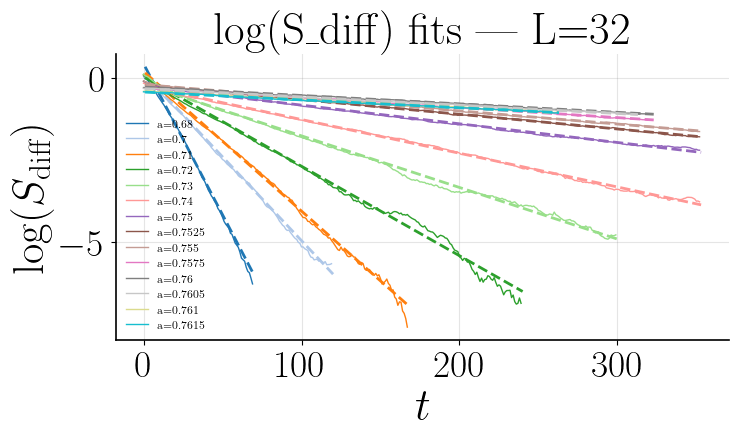

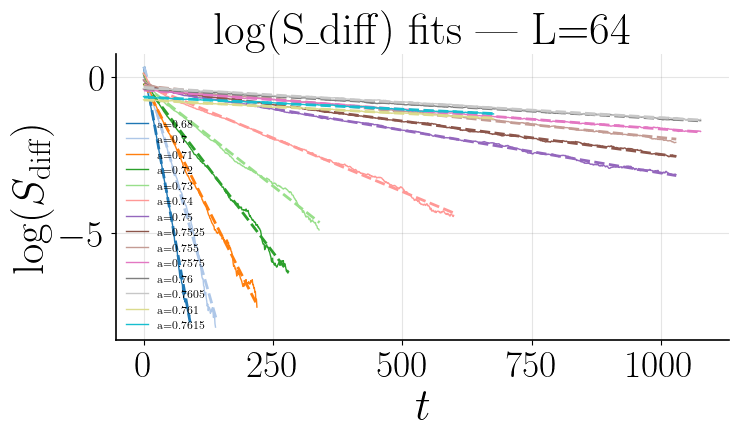

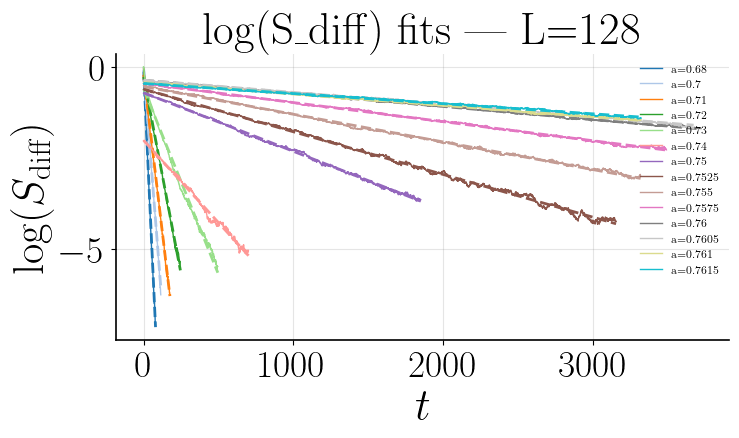

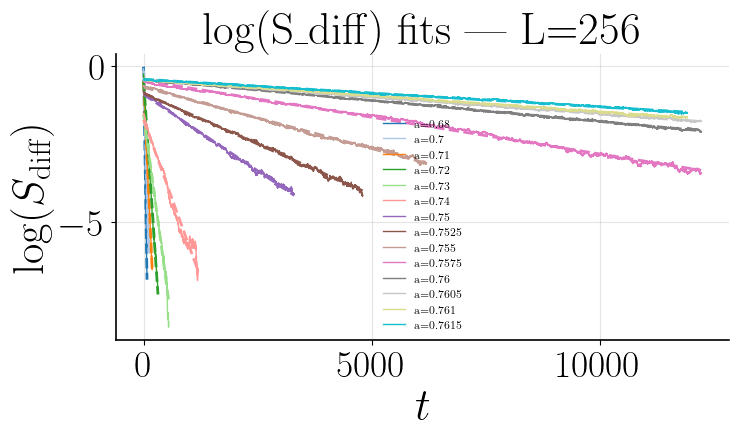

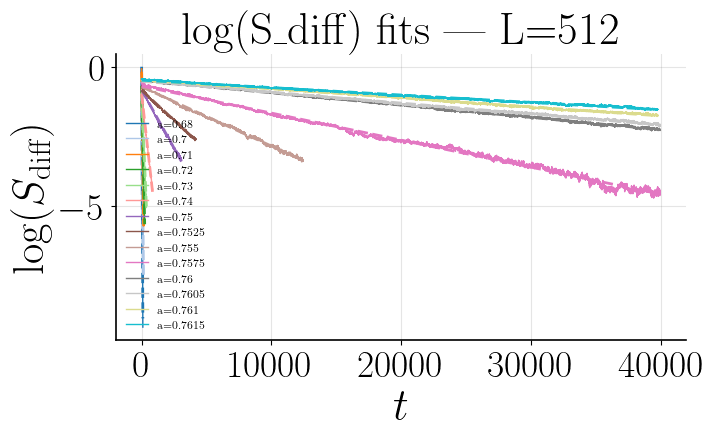

In [ ]:
fitted_a_vals_to_plot = [a for a in a_vals if 0.67 <= a <= 0.7615]

for L in [n * N_val for n in num_unit_cells_vals]:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(f"log(S_diff) fits | L={L}")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$\log(S_{\mathrm{diff}})$")

    for i, a_val in enumerate(fitted_a_vals_to_plot):
        t_min, t_max = times_to_fit[z_fit_val][L][a_val]
        log_s = np.log(collected_S_diffs_mean[L][a_val][t_min - 1 : t_max])
        xs    = np.arange(1, len(log_s) + 1)
        c     = plt.cm.tab20(i / len(fitted_a_vals_to_plot))

        ax.plot(log_s,  color=c, linewidth=1, label=f"a={a_val}")
        ax.plot(xs, all_log_s_diff_offsets[L][a_val] + all_log_s_diff_slopes[L][a_val] * xs,
                color=c, linewidth=2, linestyle="--")

    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

### 10d. Plot Log(S_{diff}) Vs t again

KeyError: 0.69

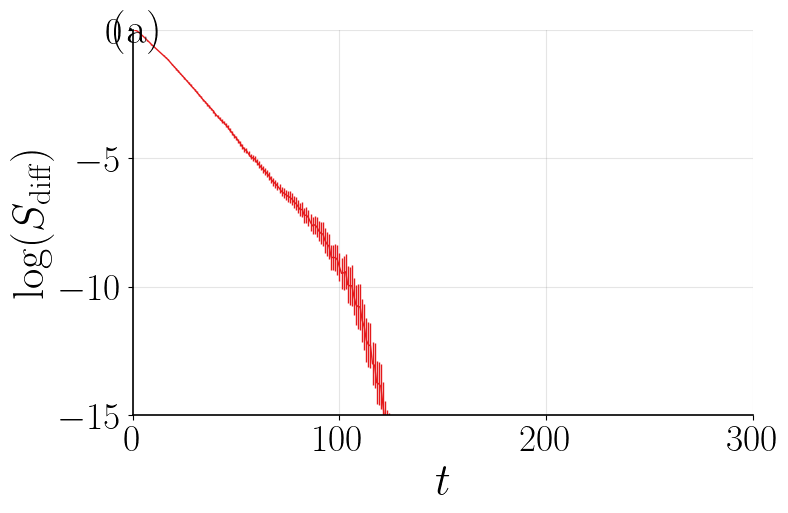

In [ ]:
num_unit_cell_plot = 64
L_plot             = num_unit_cell_plot * N_val
n_plot             = int(round(L_plot ** 1.6))

plt.rcParams['legend.fontsize'] = 14

# ── Zoomed log(S_diff) vs t ──────────────────────────────────────────────────
a_vals_zoom = [0.68, 0.69, 0.7, 0.71, 0.72, 0.74, 0.76]
a_val_to_fit = 0.69
a_val_to_sholder = 0.7
sholder_offset = 76


x_max, y_min = 300, -15

fig, ax = plt.subplots(figsize=(8, 5))
# ax.set_title(rf"$\log(S_{{\mathrm{{diff}}}})$ (zoomed) — $N={N_val}$, $L={L_plot}$")
ax.text(0.1, 0.855, "(a)", fontsize=plt.rcParams["axes.labelsize"],
    transform=fig.transFigure)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\log(S_{\mathrm{diff}})$")
ax.set_xlim(0, x_max)
ax.set_ylim(y_min, 0)

plot_cmap = plt.get_cmap("Set1", len(a_vals_zoom))
# plot_cmap = plt.get_cmap("Accent", len(a_vals_zoom))
for i, a in enumerate(a_vals_zoom):
    c = plot_cmap(i)
    ts = np.linspace(0, 350, 350)
    y    = np.log(collected_S_diffs_mean[L_plot][a][:350])
    yerr = collected_log_S_diff_errs[L_plot][a][:350]
    ax.errorbar(np.arange(350), y, yerr=yerr, label=f"a={a}", linewidth=1, capsize=0, color=c)

    if a == a_val_to_fit:
        ax.plot(ts, 0.2+all_log_s_diff_offsets[L][a] + all_log_s_diff_slopes[L][a] * ts, linestyle=(0, (8, 3)), linewidth=2.5, color=c, )
        
    if a == a_val_to_sholder:
        ax.plot(ts, sholder_offset + np.log(a) * ts, linestyle=(0, (8, 3, 2, 3)), linewidth=2.5, color=c, )

ax.legend(loc="lower left")
out = (
    f"figs/log_delta_evolved_spins/N{N_val}/SeveralAs/IC{num_initial_conds}/L{L_plot}/"
    f"Zoomed_Log_S_diff_N{N_val}_L{L_plot}_z{z_fit_name}.png"
)
make_path_exist(out); fig.tight_layout(); fig.savefig(out, dpi=150)
print(f"Saved: {out}")
plt.show()

---
## 11. Decay Timescale ξ_t vs `a`

ξ_t = –1 / slope, with propagated error δξ_t = δ(slope) / slope².

Saved: figs/decay_per_a/N4/SeveralAs/IC1000/SeveralLs/decay_per_a_N4_IC1000_z1p7.png


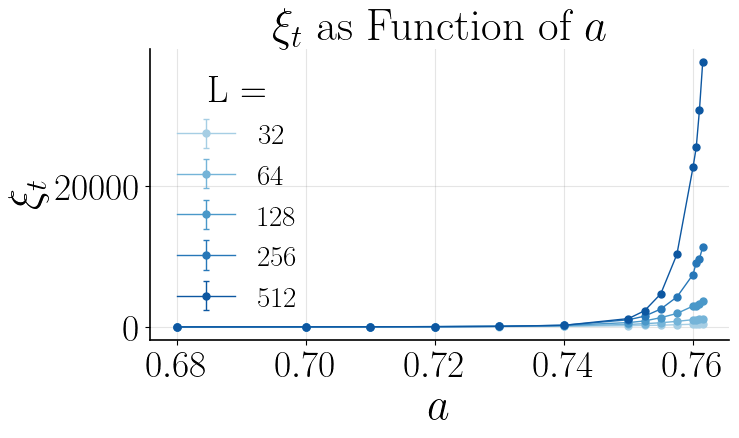

In [ ]:
L_vals = [n * N_val for n in num_unit_cells_vals]

# Pre-compute ξ_t and its error for each (L, a)
xi_tau     = {L: {a: -1/all_log_s_diff_slopes[L][a] for a in decay_a_vals} for L in L_vals}
delta_xi   = {L: {a: all_log_s_diff_slope_errs[L][a] / all_log_s_diff_slopes[L][a]**2
                  for a in decay_a_vals} for L in L_vals}

# ── Save ξ_t data ───────────────────────────────────────────────────────────
for L in L_vals:
    data = {a: [xi_tau[L][a], delta_xi[L][a]] for a in decay_a_vals}
    fp   = (
        f"data_to_collapse/xi_tau_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
        f"lambda_var_per_a_N{N_val}_IC{num_initial_conds}_L{L}_z{z_fit_name}.csv"
    )
    save_simple_dict_to_csv(data, fp)

# ── Plot: ξ_t vs a (main) ────────────────────────────────────────────────────
fig_xi, ax_xi = plt.subplots(figsize=(8, 5))
ax_xi.set_title(r"$\xi_t$ as Function of $a$")
ax_xi.set_xlabel(r"$a$")
ax_xi.set_ylabel(r"$\xi_t$")

for i, L in enumerate(L_vals):
    xs   = sorted(decay_a_vals)
    ys   = [xi_tau[L][a] for a in xs]
    yerr = [delta_xi[L][a] for a in xs]
    ax_xi.errorbar(xs, ys, yerr=yerr, marker="o", markersize=5, linewidth=1,
                   label=str(L), color=blue_colors[i], capsize=2)

ax_xi.legend(title="L =")
out = (
    f"figs/decay_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
    f"decay_per_a_N{N_val}_IC{num_initial_conds}_z{z_fit_name}.png"
)
make_path_exist(out)
fig_xi.tight_layout(); fig_xi.savefig(out, dpi=150)
print(f"Saved: {out}")
plt.show()

---
## 12. log(ξ_t) Plots and FSS Collapse with Inset


In [ ]:
# ── FSS / collapse parameters ────────────────────────────────────────────────
a_crit, a_crit_err = 0.758, 0.0005
z,   z_err         = 1.18,  0.1
nu_par = 2.22
nu,  nu_err        = nu_par/z,   0.01

decay_a_vals_fss = [a for a in a_vals if 0.72 <= a <= a_crit]
L_vals_fss       = [*L_vals]   # subset used in Julia script
colors_fss       = [mcolors.to_rgba(c) for c in
                    plt.cm.Blues(np.linspace(0.45, 0.85, len(L_vals_fss)))]

def xi_ys(L):   return np.array([xi_tau[L][a] for a in sorted(decay_a_vals_fss)])
def xi_err(L):  return np.array([delta_xi[L][a] for a in sorted(decay_a_vals_fss)])
def xs_fss(L):  return np.array([(a - a_crit) * L**(1/nu) for a in sorted(decay_a_vals_fss)])

Saved: figs/decay_per_a/N4/SeveralAs/IC1000/SeveralLs/log_decay_per_a_N4_IC1000_z1p7.png


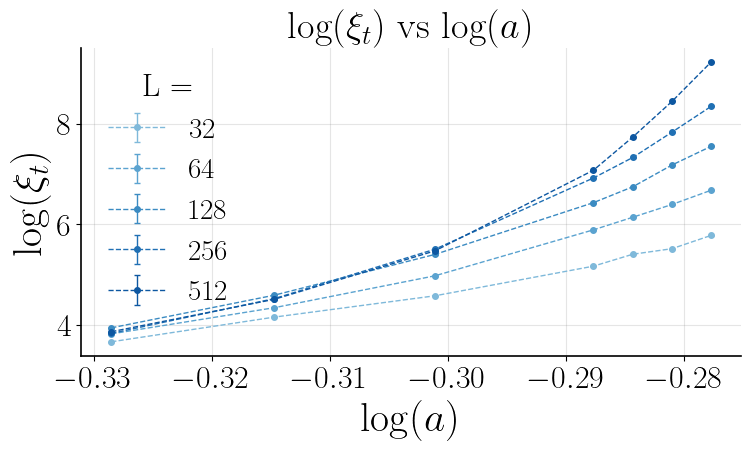

In [ ]:
# ── log(ξ_t) vs log(a) ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(r"$\log(\xi_t)$ vs $\log(a)$")
ax.set_xlabel(r"$\log(a)$")
ax.set_ylabel(r"$\log(\xi_t)$")

for i, L in enumerate(L_vals_fss):
    ys   = np.log(xi_ys(L))
    yerr = xi_err(L) / xi_ys(L)
    ax.errorbar(np.log(sorted(decay_a_vals_fss)), ys, yerr=yerr,
                marker="o", markersize=4, linewidth=1, linestyle="--",
                label=str(L), color=colors_fss[i], capsize=2)
ax.legend(title="L =")
out = (
    f"figs/decay_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
    f"log_decay_per_a_N{N_val}_IC{num_initial_conds}_z{z_fit_name}.png"
)
make_path_exist(out); fig.tight_layout(); fig.savefig(out, dpi=150)
print(f"Saved: {out}")
plt.show()

Saved: figs/decay_per_a/N4/SeveralAs/IC1000/SeveralLs/loglin_decay_per_a_N4_IC1000_z1p7.png


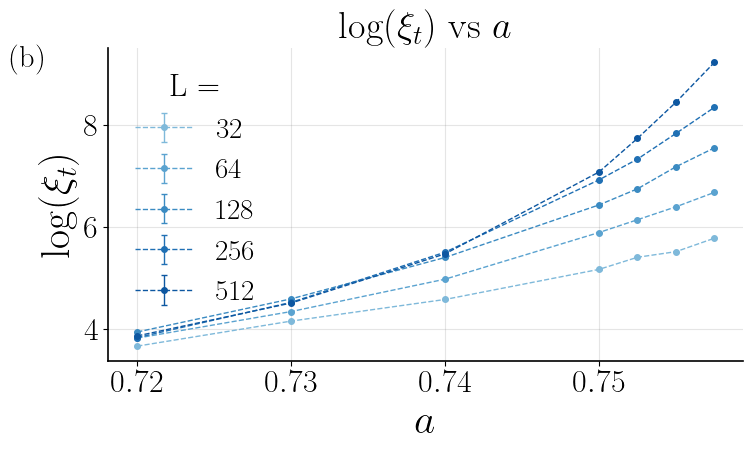

In [ ]:
# ── log(ξ_t) vs a (log-lin) — main panel for publication ────────────────────
fig_ll, ax_ll = plt.subplots(figsize=(8, 5))
ax_ll.text(-0.155, 1.01, "(b)", transform=ax_ll.transAxes, fontsize=22, va="top", ha="left")
ax_ll.set_xlabel(r"$a$")
ax_ll.set_ylabel(r"$\log(\xi_t)$")
ax_ll.set_title(r"$\log(\xi_t)$ vs $a$")

for i, L in enumerate(L_vals_fss):
    ys   = np.log(xi_ys(L))
    yerr = xi_err(L) / xi_ys(L)
    ax_ll.errorbar(sorted(decay_a_vals_fss), ys, yerr=yerr,
                   marker="o", markersize=4, linewidth=1, linestyle="--",
                   label=str(L), color=colors_fss[i], capsize=2)
ax_ll.legend(title="L =")
out = (
    f"figs/decay_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
    f"loglin_decay_per_a_N{N_val}_IC{num_initial_conds}_z{z_fit_name}.png"
)
make_path_exist(out); fig_ll.tight_layout(); fig_ll.savefig(out, dpi=150)
print(f"Saved: {out}")
plt.show()

Saved: figs/decay_per_a/N4/SeveralAs/IC1000/SeveralLs/decay_per_a_N4_IC1000_z1p7.png


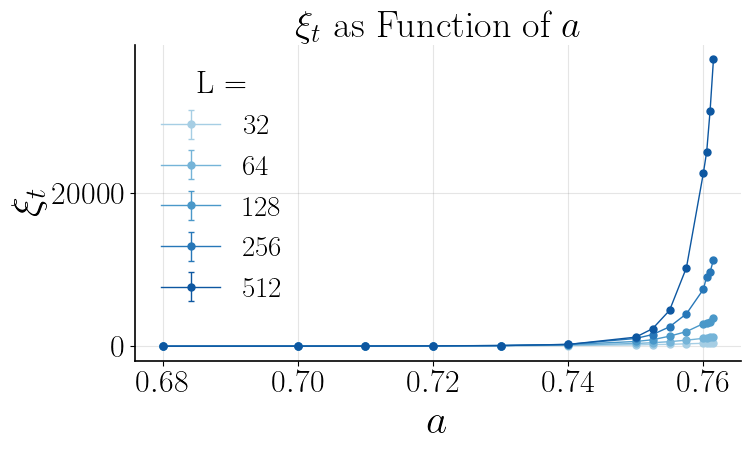

In [ ]:
# ── Plot: ξ_t vs a (main) ────────────────────────────────────────────────────
fig_xi, ax_xi = plt.subplots(figsize=(8, 5))
ax_xi.set_title(r"$\xi_t$ as Function of $a$")
ax_xi.set_xlabel(r"$a$")
ax_xi.set_ylabel(r"$\xi_t$")

for i, L in enumerate(L_vals):
    xs   = sorted(decay_a_vals)
    ys   = [xi_tau[L][a] for a in xs]
    yerr = [delta_xi[L][a] for a in xs]
    ax_xi.errorbar(xs, ys, yerr=yerr, marker="o", markersize=5, linewidth=1,
                   label=str(L), color=blue_colors[i], capsize=2)

ax_xi.legend(title="L =")
out = (
    f"figs/decay_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
    f"decay_per_a_N{N_val}_IC{num_initial_conds}_z{z_fit_name}.png"
)
make_path_exist(out)
fig_xi.tight_layout(); fig_xi.savefig(out, dpi=150)
print(f"Saved: {out}")
plt.show()

Saved: figs/decay_per_a/N4/SeveralAs/IC1000/SeveralLs/scaled_decay_per_a_N4_IC1000_z1p7.png


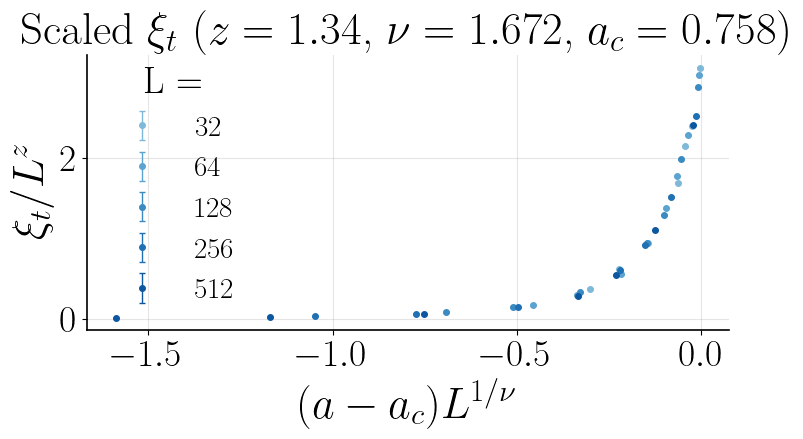

In [ ]:
# ── FSS: ξ_t / L^z vs (a-a_c) L^{1/ν} ──────────────────────────────────────
a_crit, a_crit_err = 0.7580212502058766, 0.0005
z,   z_err         = 1.34,  0.1
nu_par = 2.24
nu,  nu_err        = nu_par/z,   0.01

decay_a_vals_fss = [a for a in a_vals if 0.72 <= a <= a_crit]

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(
    rf"Scaled $\xi_t$ ($z={round(z,3)}$, $\nu={round(nu,3)}$, $a_c={round(a_crit,4)}$)"
)
ax.set_xlabel(r"$(a-a_c)L^{1/\nu}$")
ax.set_ylabel(r"$\xi_t / L^z$")

for i, L in enumerate(L_vals_fss):
    ys   = xi_ys(L) / L**z
    yerr = xi_err(L) / L**z
    ax.errorbar(xs_fss(L), ys, yerr=yerr,
                marker="o", markersize=4, linewidth=1, linestyle="",
                label=str(L), color=colors_fss[i], capsize=2)
ax.legend(title="L =")
out = (
    f"figs/decay_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
    f"scaled_decay_per_a_N{N_val}_IC{num_initial_conds}_z{z_fit_name}.png"
)
make_path_exist(out); fig.tight_layout(); fig.savefig(out, dpi=150)
print(f"Saved: {out}")
plt.show()

Saved: figs/decay_per_a/N4/SeveralAs/IC1000/SeveralLs/inset_scaled_decay_per_a_N4_IC1000_z1p7.png


/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36146/1371924077.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


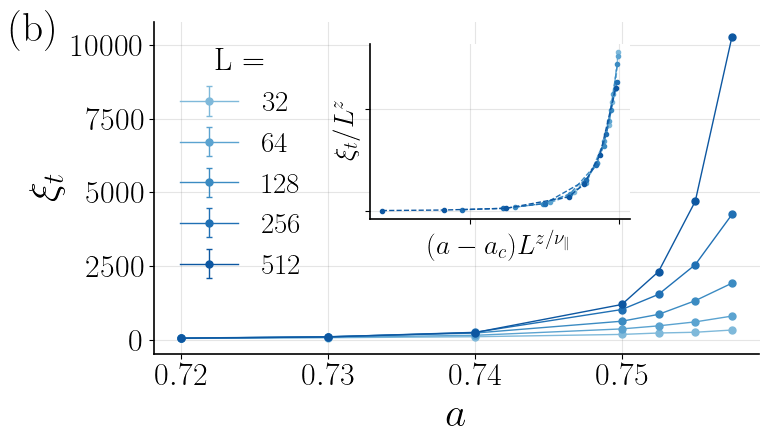

In [ ]:
# ── ξ_t main panel + FSS inset (publication figure) ─────────────────────────
fig_xi2, ax_xi2 = plt.subplots(figsize=(8, 5))
# ax_xi2.set_title(rf"$\xi_t$ as Function of $a$: z=${z}$")
ax_xi2.text(0.02, 0.855, "(b)", fontsize=plt.rcParams["axes.labelsize"],
    transform=fig_xi2.transFigure)

ax_xi2.set_xlabel(r"$a$")
ax_xi2.set_ylabel(r"$\xi_t$")

for i, L in enumerate(L_vals_fss):
    ax_xi2.errorbar(sorted(decay_a_vals_fss), xi_ys(L), yerr=xi_err(L),
                    marker="o", markersize=5, linewidth=1,
                    label=str(L), color=colors_fss[i], capsize=2)
ax_xi2.legend(title="L =")

# Inset
inset_rect = [0.47, 0.5, 0.325, 0.35]  
ax_xi_in = fig_xi2.add_axes(inset_rect)
ax_xi_in.tick_params(labelleft=False, labelbottom=False)
ax_xi_in.set_xlabel(r"$(a-a_c)L^{z/\nu_{\|}}$", fontsize=20)
ax_xi_in.set_ylabel(r"$\xi_t / L^z$", fontsize=20)

for i, L in enumerate(L_vals_fss):
    ax_xi_in.errorbar(xs_fss(L), xi_ys(L)/L**z, yerr=xi_err(L)/L**z,
                      marker="o", markersize=3, linewidth=1, linestyle="--",
                      color=colors_fss[i], capsize=1)

out = (
    f"figs/decay_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
    f"inset_scaled_decay_per_a_N{N_val}_IC{num_initial_conds}_z{z_fit_name}.png"
)
plt.tight_layout()
make_path_exist(out); fig_xi2.savefig(out, dpi=150)
print(f"Saved: {out}")
plt.show()

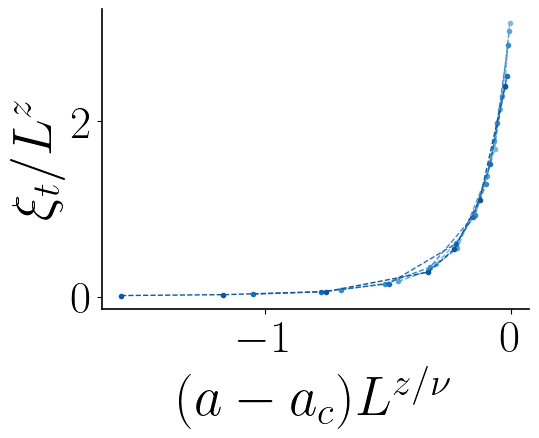

In [ ]:
# Inset
fig, ax = plt.subplots(figsize=(6, 5))
ax.tick_params(labelleft=True, labelbottom=True, labelsize=33)
ax.set_xlabel(r"$(a-a_c)L^{z/\nu}$", fontsize=40)
ax.set_ylabel(r"$\xi_t / L^z$", fontsize=40)
ax.grid(False)

for i, L in enumerate(L_vals_fss):
    ax.errorbar(xs_fss(L), xi_ys(L)/L**z, yerr=xi_err(L)/L**z,
                      marker="o", markersize=3, linewidth=1, linestyle="--",
                      color=colors_fss[i], capsize=1)

# out = (
#     f"figs/decay_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
#     f"inset_scaled_decay_per_a_N{N_val}_IC{num_initial_conds}_z{z_fit_name}.png"
# )
plt.tight_layout()
# make_path_exist(out); fig_xi2.savefig(out, dpi=150)
# print(f"Saved: {out}")
plt.show()

Saved: figs/decay_per_a/N4/SeveralAs/IC1000/SeveralLs/fss_loglin_decay_per_a_N4_IC1000_z1p7.png


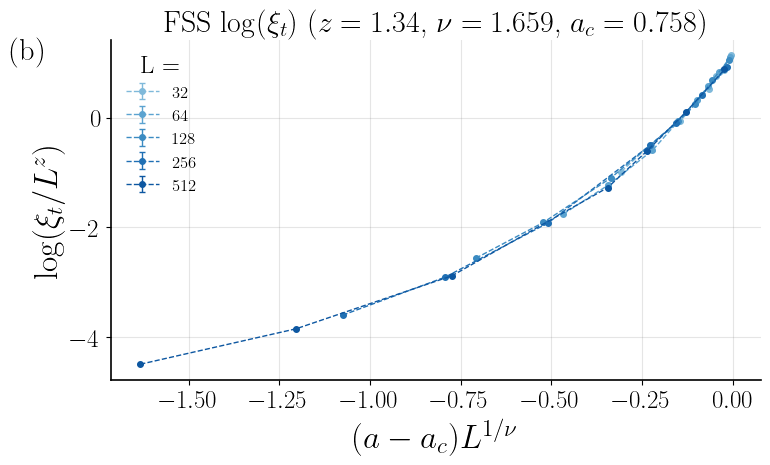

Saved: figs/decay_per_a/N4/SeveralAs/IC1000/SeveralLs/inset_fss_loglin_decay_per_a_N4_IC1000_z1p7.png


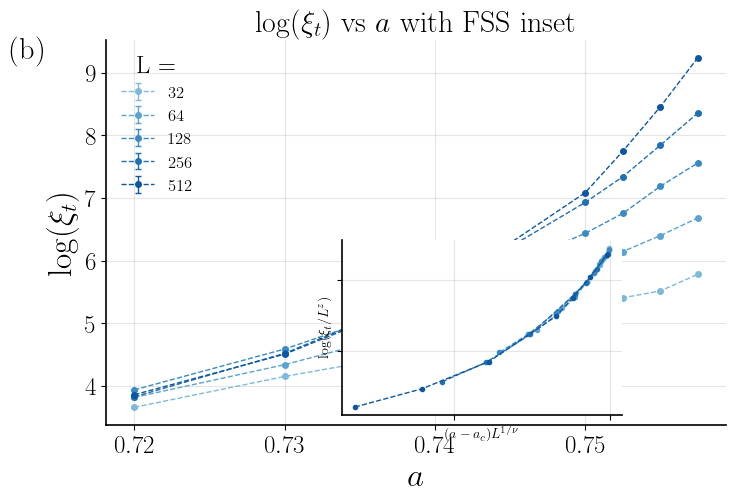

In [ ]:
# ── log(ξ_t/L^z) vs (a-a_c)L^{1/ν} (log-lin collapse) + inset ──────────────
fig_ll2, ax_ll2 = plt.subplots(figsize=(8, 5))
ax_ll2.text(-0.155, 1.01, "(b)", transform=ax_ll2.transAxes, fontsize=22, va="top", ha="left")
ax_ll2.set_title(
    rf"FSS $\log(\xi_t)$ ($z={round(z,3)}$, $\nu={round(nu,3)}$, $a_c={round(a_crit,4)}$)"
)
ax_ll2.set_xlabel(r"$(a-a_c)L^{1/\nu}$")
ax_ll2.set_ylabel(r"$\log(\xi_t / L^z)$")

for i, L in enumerate(L_vals_fss):
    ys   = np.log(xi_ys(L) / L**z)
    yerr = xi_err(L) / xi_ys(L)
    ax_ll2.errorbar(xs_fss(L), ys, yerr=yerr,
                    marker="o", markersize=4, linewidth=1, linestyle="--",
                    label=str(L), color=colors_fss[i], capsize=2)

ax_ll2.legend(title="L =")
out = (
    f"figs/decay_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
    f"fss_loglin_decay_per_a_N{N_val}_IC{num_initial_conds}_z{z_fit_name}.png"
)
make_path_exist(out); fig_ll2.tight_layout(); fig_ll2.savefig(out, dpi=150)
print(f"Saved: {out}")
plt.show()

# Publication figure: log-lin main + inset
fig_pub, ax_pub = plt.subplots(figsize=(8, 5))
ax_pub.text(-0.155, 1.01, "(b)", transform=ax_pub.transAxes, fontsize=22, va="top", ha="left")
ax_pub.set_xlabel(r"$a$")
ax_pub.set_ylabel(r"$\log(\xi_t)$")
ax_pub.set_title(r"$\log(\xi_t)$ vs $a$ with FSS inset")

for i, L in enumerate(L_vals_fss):
    ys   = np.log(xi_ys(L))
    yerr = xi_err(L) / xi_ys(L)
    ax_pub.errorbar(sorted(decay_a_vals_fss), ys, yerr=yerr,
                    marker="o", markersize=4, linewidth=1, linestyle="--",
                    label=str(L), color=colors_fss[i], capsize=2)
ax_pub.legend(title="L =")

inset_rect2 = [0.42, 0.13, 0.35, 0.35]   # ⚠️ FLAG: adjust to taste
ax_in2 = fig_pub.add_axes(inset_rect2)
ax_in2.tick_params(labelleft=False, labelbottom=False)
ax_in2.set_xlabel(r"$(a-a_c)L^{1/\nu}$", fontsize=10)
ax_in2.set_ylabel(r"$\log(\xi_t/L^z)$", fontsize=10)

for i, L in enumerate(L_vals_fss):
    ys   = np.log(xi_ys(L) / L**z)
    yerr = xi_err(L) / xi_ys(L)
    ax_in2.errorbar(xs_fss(L), ys, yerr=yerr,
                    marker="o", markersize=3, linewidth=1, linestyle="--",
                    color=colors_fss[i], capsize=1)

out2 = (
    f"figs/decay_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
    f"inset_fss_loglin_decay_per_a_N{N_val}_IC{num_initial_conds}_z{z_fit_name}.png"
)
make_path_exist(out2); fig_pub.savefig(out2, dpi=150)
print(f"Saved: {out2}")
plt.show()